# Parte 2 — Classificação de Imagens Médicas com CNN
## Dataset: BloodMNIST (MedMNIST)

Este notebook implementa a Parte 2 da atividade, em **PyTorch** (mesma stack da Parte 1):

1. Reconstrução do pipeline de dados da Parte 1 (para o notebook funcionar de forma independente no Colab)
2. Treinamento de uma **CNN do zero**
3. Treinamento via **Transfer Learning** (ResNet18 pré-treinada na ImageNet)
4. Avaliação com acurácia, matriz de confusão, precisão, recall e F1-score
5. Comparação entre os dois modelos
6. Protótipo simples de apresentação dos resultados



In [1]:
!pip install medmnist Pillow numpy matplotlib scikit-learn seaborn torchvision torch -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.1 MB/s eta 0:00:00


In [2]:
import os
import copy
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
import medmnist
from medmnist import BloodMNIST, INFO
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import pandas as pd

print(f'MedMNIST versão: {medmnist.__version__}')
print(f'PyTorch versão: {torch.__version__}')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
# Dica: em Colab, ative GPU em Ambiente de execução > Alterar tipo de ambiente de execução > GPU


MedMNIST versão: 3.0.2
PyTorch versão: 2.11.0+cpu
Dispositivo: cpu


## 1. Reproduzindo o pipeline da Parte 1

Recriamos exatamente o mesmo pipeline (resize 64x64, normalização Z-score calculada no treino, augmentação só no treino) para que este notebook funcione de forma independente.

In [3]:
# ─── Parâmetros do Pipeline (idênticos à Parte 1) ──────────
TAMANHO_IMAGEM = 64
BATCH_SIZE     = 32
SEED           = 42
DATA_DIR       = './data'
N_CLASSES      = 8

torch.manual_seed(SEED)
np.random.seed(SEED)
os.makedirs(DATA_DIR, exist_ok=True)

info   = INFO['bloodmnist']
labels = info['label']
class_names = [labels[str(i)] for i in range(N_CLASSES)]
print('Classes:', class_names)


Classes: ['basophil', 'eosinophil', 'erythroblast', 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', 'lymphocyte', 'monocyte', 'neutrophil', 'platelet']


In [4]:
# Calcula média e desvio padrão do conjunto de treino (mesma lógica da Parte 1)
temp_transform = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.ToTensor()
])

dataset_temp = BloodMNIST(split='train', download=True, root=DATA_DIR, size=28, transform=temp_transform)
loader_temp  = DataLoader(dataset_temp, batch_size=512, shuffle=False)

canais_soma  = torch.zeros(3)
canais_soma2 = torch.zeros(3)
n_pixels     = 0

for imgs, _ in loader_temp:
    n_pixels     += imgs.size(0) * imgs.size(2) * imgs.size(3)
    canais_soma  += imgs.sum(dim=[0, 2, 3])
    canais_soma2 += (imgs ** 2).sum(dim=[0, 2, 3])

media = canais_soma / n_pixels
std   = (canais_soma2 / n_pixels - media ** 2).sqrt()
print(f'Média por canal: {media}')
print(f'Desvio padrão por canal: {std}')


100%|██████████| 35.5M/35.5M [00:00<00:00, 110MB/s]


Média por canal: tensor([0.7944, 0.6597, 0.6963])
Desvio padrão por canal: tensor([0.2109, 0.2369, 0.1110])


In [5]:
# Transformações finais (idênticas à Parte 1)
transform_treino = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=media.tolist(), std=std.tolist())
])

transform_eval = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.ToTensor(),
    transforms.Normalize(mean=media.tolist(), std=std.tolist())
])

ds_treino = BloodMNIST(split='train', download=False, root=DATA_DIR, size=28, transform=transform_treino)
ds_val    = BloodMNIST(split='val',   download=False, root=DATA_DIR, size=28, transform=transform_eval)
ds_teste  = BloodMNIST(split='test',  download=False, root=DATA_DIR, size=28, transform=transform_eval)

loader_treino = DataLoader(ds_treino, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
loader_val    = DataLoader(ds_val,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
loader_teste  = DataLoader(ds_teste,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f'Treino: {len(ds_treino)} | Validação: {len(ds_val)} | Teste: {len(ds_teste)}')


Treino: 11959 | Validação: 1712 | Teste: 3421


## 2. Função genérica de treino

Usada tanto para a CNN do zero quanto para o modelo de Transfer Learning. Inclui early stopping manual (interrompe se a val_loss não melhorar por algumas épocas) e restaura os melhores pesos encontrados.

In [7]:
def train_model(model, loader_treino, loader_val, criterion, optimizer, epochs, device, patience=4):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # ---- Treino ----
        model.train()
        running_loss, running_corrects, total = 0.0, 0, 0
        for imgs, lbls in loader_treino:
            imgs = imgs.to(device)
            lbls = lbls.squeeze(1).long().to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            running_corrects += (outputs.argmax(1) == lbls).sum().item()
            total += imgs.size(0)

        train_loss = running_loss / total
        train_acc = running_corrects / total

        # ---- Validação ----
        model.eval()
        val_loss_sum, val_corrects, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, lbls in loader_val:
                imgs = imgs.to(device)
                lbls = lbls.squeeze(1).long().to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                val_loss_sum += loss.item() * imgs.size(0)
                val_corrects += (outputs.argmax(1) == lbls).sum().item()
                val_total += imgs.size(0)

        val_loss = val_loss_sum / val_total
        val_acc = val_corrects / val_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Época {epoch+1}/{epochs} - loss: {train_loss:.4f} acc: {train_acc:.4f} '
              f'| val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'Early stopping na época {epoch+1} (sem melhora na val_loss há {patience} épocas)')
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history['train_acc'], label='treino')
    axes[0].plot(history['val_acc'], label='validação')
    axes[0].set_title(f'{title} - Acurácia')
    axes[0].set_xlabel('Época')
    axes[0].legend()

    axes[1].plot(history['train_loss'], label='treino')
    axes[1].plot(history['val_loss'], label='validação')
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def evaluate_model(model, loader, class_names, model_name, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.squeeze(1).long()
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu()
            y_true.extend(lbls.numpy())
            y_pred.extend(preds.numpy())

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='weighted', zero_division=0
    )

    print(f'=== {model_name} ===')
    print(f'Acurácia: {acc:.4f}')
    print(f'Precisão (weighted): {precision:.4f}')
    print(f'Recall (weighted): {recall:.4f}')
    print(f'F1-score (weighted): {f1:.4f}\n')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de Confusão - {model_name}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}


## 3. Parte 2.1 — CNN treinada do zero

Arquitetura simples: 3 blocos convolucionais (Conv2d + BatchNorm + ReLU + MaxPool) seguidos de camadas densas. Como as imagens são 64×64, após os 3 poolings (divisão por 2 cada) chegamos a mapas 8×8.

In [8]:
class CNNScratch(nn.Module):
    def __init__(self, n_classes=8):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn_scratch = CNNScratch(n_classes=N_CLASSES).to(device)
print(cnn_scratch)


CNNScratch(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropo

Época 1/15 - loss: 1.0905 acc: 0.5751 | val_loss: 0.5189 val_acc: 0.8084
Época 2/15 - loss: 0.7781 acc: 0.6928 | val_loss: 0.4369 val_acc: 0.8148
Época 3/15 - loss: 0.6875 acc: 0.7301 | val_loss: 0.4274 val_acc: 0.8370
Época 4/15 - loss: 0.6495 acc: 0.7505 | val_loss: 0.3986 val_acc: 0.8505
Época 5/15 - loss: 0.6148 acc: 0.7624 | val_loss: 0.3414 val_acc: 0.8803
Época 6/15 - loss: 0.5793 acc: 0.7744 | val_loss: 0.3231 val_acc: 0.8668
Época 7/15 - loss: 0.5685 acc: 0.7788 | val_loss: 0.3395 val_acc: 0.8738
Época 8/15 - loss: 0.5545 acc: 0.7837 | val_loss: 0.3416 val_acc: 0.8797
Época 9/15 - loss: 0.5286 acc: 0.7920 | val_loss: 0.3000 val_acc: 0.8925
Época 10/15 - loss: 0.5209 acc: 0.7988 | val_loss: 0.2808 val_acc: 0.8966
Época 11/15 - loss: 0.5102 acc: 0.8027 | val_loss: 0.3074 val_acc: 0.8995
Época 12/15 - loss: 0.4906 acc: 0.8088 | val_loss: 0.2820 val_acc: 0.9001
Época 13/15 - loss: 0.4798 acc: 0.8144 | val_loss: 0.3086 val_acc: 0.8949
Época 14/15 - loss: 0.4834 acc: 0.8120 | val_lo

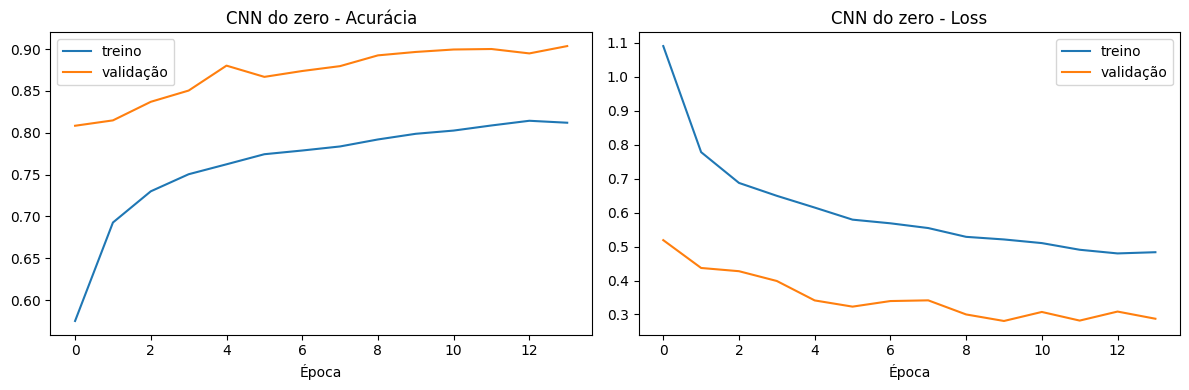

In [9]:
criterion_scratch = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(cnn_scratch.parameters(), lr=1e-3)

history_scratch = train_model(
    cnn_scratch, loader_treino, loader_val,
    criterion_scratch, optimizer_scratch,
    epochs=15, device=device, patience=4
)

plot_history(history_scratch, 'CNN do zero')


In [17]:
# Nomes abreviados só para os rótulos da matriz de confusão (o relatório de classificação continua com os nomes completos)
nomes_abreviados = {
    'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)': 'immature granulocytes (IG)'
}
class_names_plot = [nomes_abreviados.get(c, c) for c in class_names]

def evaluate_model(model, loader, class_names, model_name, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            lbls = lbls.squeeze(1).long()
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu()
            y_true.extend(lbls.numpy())
            y_pred.extend(preds.numpy())

    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)

    print(f'=== {model_name} ===')
    print(f'Acurácia: {acc:.4f}')
    print(f'Precisão (weighted): {precision:.4f}')
    print(f'Recall (weighted): {recall:.4f}')
    print(f'F1-score (weighted): {f1:.4f}\n')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names_plot, yticklabels=class_names_plot,
                ax=ax, annot_kws={"size": 9})
    ax.set_title(f'Matriz de Confusão - {model_name}')
    ax.set_ylabel('Real')
    ax.set_xlabel('Previsto')
    plt.setp(ax.get_xticklabels(), rotation=40, ha='right', rotation_mode='anchor')
    plt.setp(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

### Avaliação — CNN do zero

=== CNN do zero ===
Acurácia: 0.8904
Precisão (weighted): 0.9007
Recall (weighted): 0.8904
F1-score (weighted): 0.8900

                                                                     precision    recall  f1-score   support

                                                           basophil       0.67      0.90      0.77       244
                                                         eosinophil       0.99      0.98      0.99       624
                                                       erythroblast       0.99      0.90      0.94       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.71      0.81      0.75       579
                                                         lymphocyte       0.92      0.77      0.84       243
                                                           monocyte       0.89      0.56      0.68       284
                                                         neutrophil       0.96      0.98      0.97       666
       

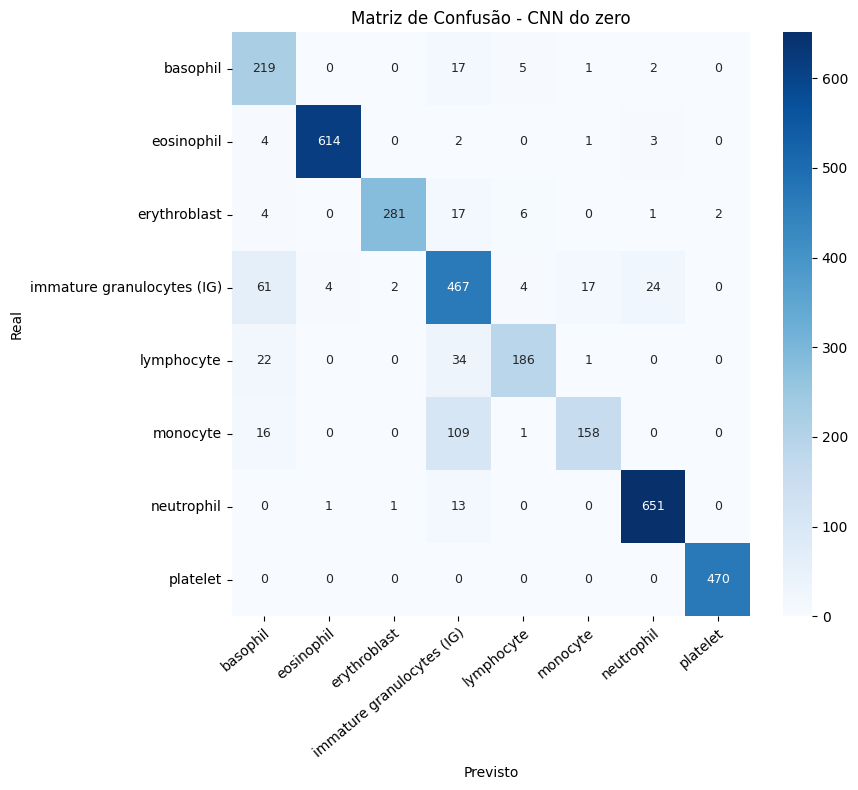

In [18]:
results_scratch = evaluate_model(cnn_scratch, loader_teste, class_names, 'CNN do zero', device)


## 4. Parte 2.2 — Transfer Learning (ResNet18)

Usamos a ResNet18 pré-treinada na ImageNet como extrator de características. Como o modelo foi treinado com a normalização da ImageNet, criamos um conjunto de transformações específico para esta etapa (mesmo resize/augmentação, mas normalizando com a média/desvio da ImageNet em vez dos calculados na Parte 1).

In [11]:
# Transformações específicas para Transfer Learning (normalização ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

transform_treino_tl = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

transform_eval_tl = transforms.Compose([
    transforms.Resize((TAMANHO_IMAGEM, TAMANHO_IMAGEM)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

ds_treino_tl = BloodMNIST(split='train', download=False, root=DATA_DIR, size=28, transform=transform_treino_tl)
ds_val_tl    = BloodMNIST(split='val',   download=False, root=DATA_DIR, size=28, transform=transform_eval_tl)
ds_teste_tl  = BloodMNIST(split='test',  download=False, root=DATA_DIR, size=28, transform=transform_eval_tl)

loader_treino_tl = DataLoader(ds_treino_tl, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
loader_val_tl    = DataLoader(ds_val_tl,    batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
loader_teste_tl  = DataLoader(ds_teste_tl,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [12]:
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Congela todas as camadas convolucionais (mantém os pesos pré-treinados)
for param in resnet.parameters():
    param.requires_grad = False

# Substitui a camada final pela nossa classificação de 8 classes
resnet.fc = nn.Linear(resnet.fc.in_features, N_CLASSES)
resnet = resnet.to(device)

print(resnet.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 171MB/s]


Linear(in_features=512, out_features=8, bias=True)


Época 1/10 - loss: 1.1125 acc: 0.6145 | val_loss: 1.0687 val_acc: 0.6379
Época 2/10 - loss: 0.8513 acc: 0.6993 | val_loss: 0.9840 val_acc: 0.6671
Época 3/10 - loss: 0.8109 acc: 0.7148 | val_loss: 0.9518 val_acc: 0.6776
Época 4/10 - loss: 0.7969 acc: 0.7208 | val_loss: 0.9223 val_acc: 0.6822
Época 5/10 - loss: 0.7779 acc: 0.7247 | val_loss: 0.8806 val_acc: 0.6951
Época 6/10 - loss: 0.7880 acc: 0.7272 | val_loss: 0.9182 val_acc: 0.6741
Época 7/10 - loss: 0.7662 acc: 0.7324 | val_loss: 0.8732 val_acc: 0.6963
Época 8/10 - loss: 0.7864 acc: 0.7226 | val_loss: 0.9053 val_acc: 0.6957
Época 9/10 - loss: 0.7684 acc: 0.7283 | val_loss: 0.8434 val_acc: 0.7074
Época 10/10 - loss: 0.7672 acc: 0.7282 | val_loss: 0.9356 val_acc: 0.6717


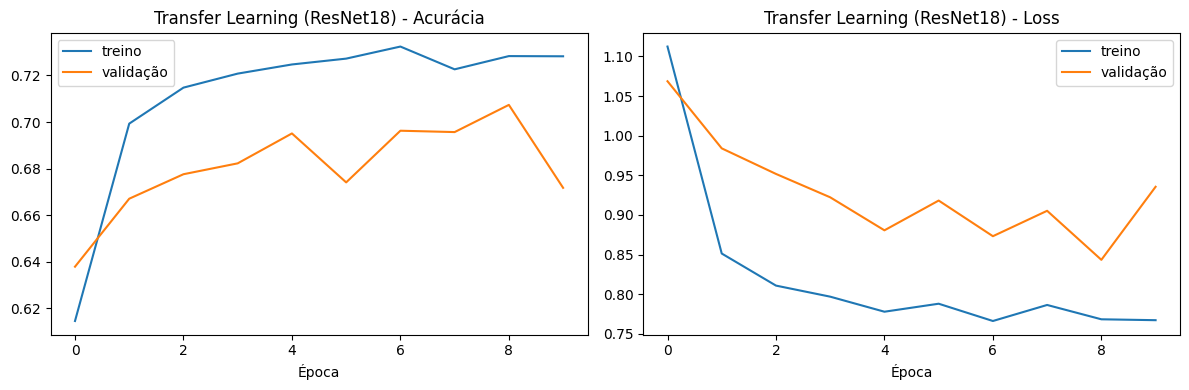

In [13]:
criterion_tl = nn.CrossEntropyLoss()
# Otimiza apenas os parâmetros da camada final (as demais estão congeladas)
optimizer_tl = optim.Adam(resnet.fc.parameters(), lr=1e-3)

history_transfer = train_model(
    resnet, loader_treino_tl, loader_val_tl,
    criterion_tl, optimizer_tl,
    epochs=10, device=device, patience=4
)

plot_history(history_transfer, 'Transfer Learning (ResNet18)')


### Avaliação — Transfer Learning

> **Nota:** se quiser tentar melhorar a acurácia, uma extensão simples é descongelar a última camada convolucional (`resnet.layer4`) e treiná-la junto com a `fc`, com uma taxa de aprendizado bem menor (ex: 1e-5).

=== Transfer Learning (ResNet18) ===
Acurácia: 0.7121
Precisão (weighted): 0.7105
Recall (weighted): 0.7121
F1-score (weighted): 0.7028

                                                                     precision    recall  f1-score   support

                                                           basophil       0.67      0.37      0.48       244
                                                         eosinophil       0.87      0.92      0.90       624
                                                       erythroblast       0.63      0.55      0.59       311
immature granulocytes(myelocytes, metamyelocytes and promyelocytes)       0.56      0.73      0.63       579
                                                         lymphocyte       0.54      0.51      0.52       243
                                                           monocyte       0.60      0.35      0.44       284
                                                         neutrophil       0.76      0.82      0.79 

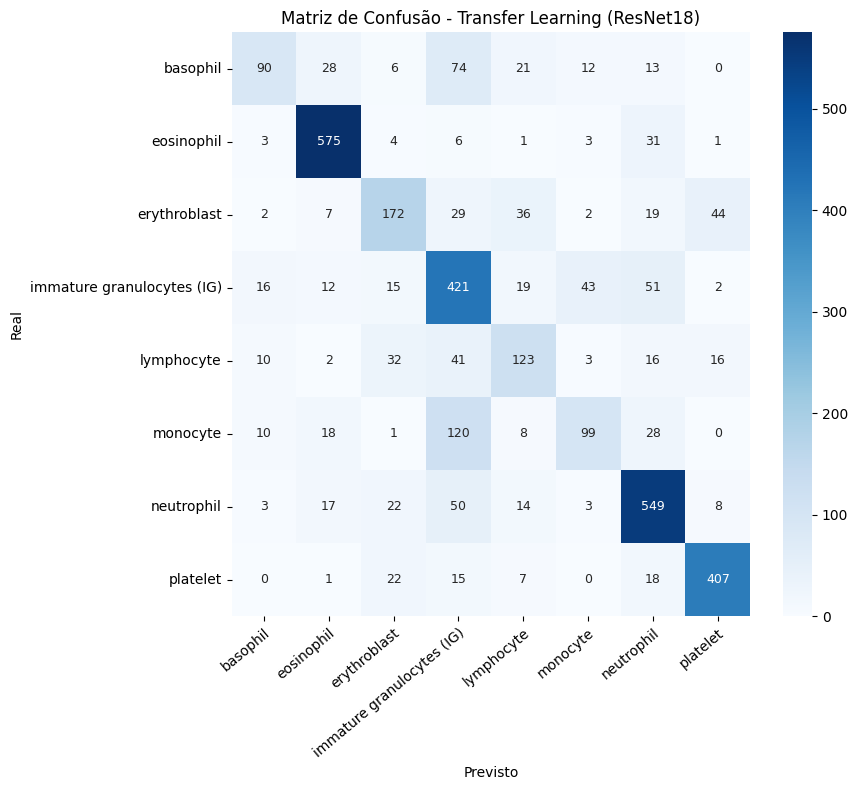

In [19]:
results_transfer = evaluate_model(resnet, loader_teste_tl, class_names, 'Transfer Learning (ResNet18)', device)


## 5. Comparação entre os dois modelos

                          model  accuracy  precision    recall        f1
0                   CNN do zero  0.890383   0.900733  0.890383  0.889997
1  Transfer Learning (ResNet18)  0.712072   0.710496  0.712072  0.702805


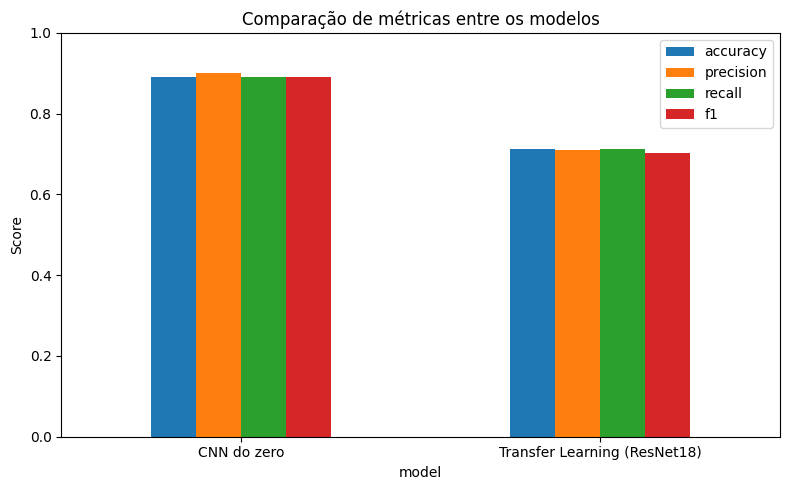

In [15]:
df_comparacao = pd.DataFrame([results_scratch, results_transfer])
print(df_comparacao)

df_comparacao.set_index('model')[['accuracy', 'precision', 'recall', 'f1']].plot(
    kind='bar', figsize=(8, 5), ylim=(0, 1)
)
plt.title('Comparação de métricas entre os modelos')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 6. Protótipo de apresentação dos resultados

Mostra algumas imagens do conjunto de teste com a classe real vs. a prevista pelo modelo de Transfer Learning. Como as imagens estão normalizadas, desnormalizamos apenas para a visualização.

/tmp/ipykernel_11122/1333772922.py:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  real = class_names[int(lbl)]


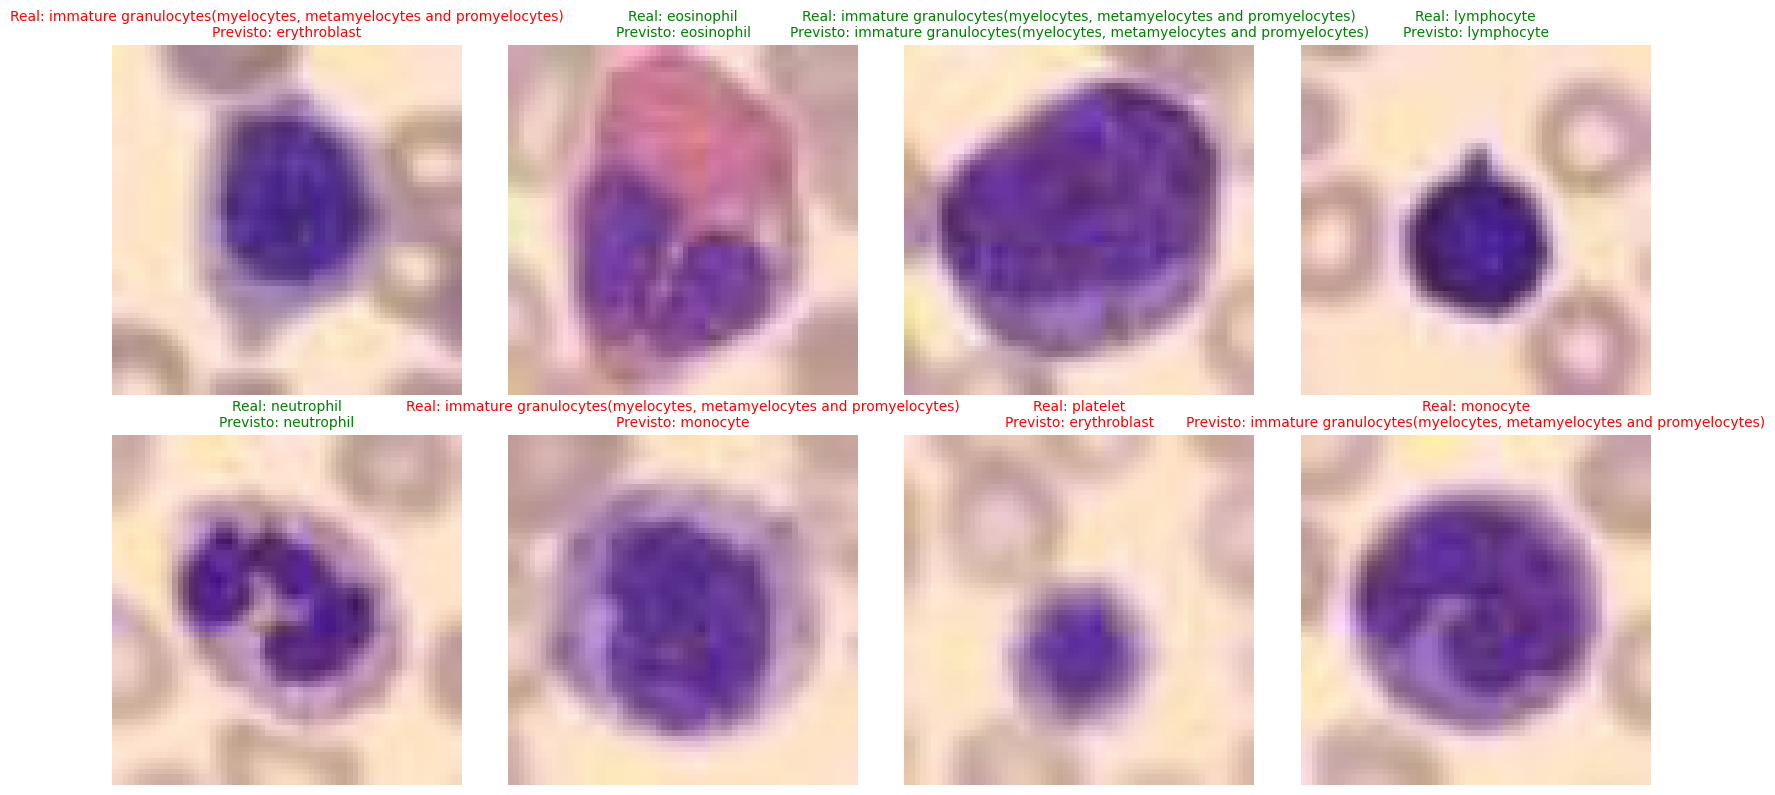

In [16]:
def mostrar_predicoes(model, dataset, class_names, mean, std, n=8, device='cpu'):
    model.eval()
    indices = np.random.choice(len(dataset), size=n, replace=False)

    plt.figure(figsize=(16, 8))
    for i, idx in enumerate(indices):
        img_tensor, lbl = dataset[idx]
        with torch.no_grad():
            output = model(img_tensor.unsqueeze(0).to(device))
            pred = output.argmax(1).item()

        # Desnormaliza para visualização
        img_vis = img_tensor.permute(1, 2, 0).numpy()
        img_vis = img_vis * np.array(std) + np.array(mean)
        img_vis = np.clip(img_vis, 0, 1)

        real = class_names[int(lbl)]
        previsto = class_names[pred]
        cor = 'green' if real == previsto else 'red'

        plt.subplot(2, n // 2, i + 1)
        plt.imshow(img_vis)
        plt.title(f'Real: {real}\nPrevisto: {previsto}', color=cor, fontsize=10)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

mostrar_predicoes(resnet, ds_teste_tl, class_names, IMAGENET_MEAN, IMAGENET_STD, n=8, device=device)
